# SupplyPrescript
## Notebook 8: Closed-Loop Analytics & Decision Logging

### Objective
Notebook 8 introduces the closed-loop analytics component of SupplyPrescript. It records predictions, recommendations, manager decisions, actual outcomes, and feedback for future improvement.

### Closed-Loop Flow
Prediction → Recommendation → Manager Decision → Actual Outcome → Evaluation → Feedback Dataset → Future Improvement

### Important Note
The current project does not contain real historical manager decisions or operational outcomes. Therefore, demonstration values are generated for testing and are clearly labelled as prototype data.


## 8.1 Import Required Libraries


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully.")


Libraries imported successfully.


## 8.2 Define Project Paths


In [2]:
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
DATA_DIR = os.path.join(BASE_DIR, "data")
PROCESSED_DIR = os.path.join(DATA_DIR, "processed")

print("Project directory:", BASE_DIR)
print("Processed directory:", PROCESSED_DIR)


Project directory: c:\Users\USER\OneDrive\Desktop\VSCode\c++\SupplyPrescript
Processed directory: c:\Users\USER\OneDrive\Desktop\VSCode\c++\SupplyPrescript\data\processed


## 8.3 Load Notebook 7 Decision Results


In [3]:
INPUT_PATH = os.path.join(PROCESSED_DIR, "SupplyPrescript_decision_results.csv")

if not os.path.exists(INPUT_PATH):
    raise FileNotFoundError(
        f"Decision results not found at: {INPUT_PATH}. Run Notebook 7 first."
    )

decision_results = pd.read_csv(INPUT_PATH)
print("Decision results shape:", decision_results.shape)
print(decision_results.columns.tolist())
decision_results.head()


Decision results shape: (25, 8)
['shipment_index', 'delay_probability', 'predicted_delay', 'risk_level', 'recommended_action', 'additional_cost', 'expected_delay_risk', 'optimization_status']


,shipment_index,delay_probability,predicted_delay,risk_level,recommended_action,additional_cost,expected_delay_risk,optimization_status
0,0,0.000245,0,Low Risk,standard_shipping,0,0.000245,Optimal
1,1,0.000367,0,Low Risk,standard_shipping,0,0.000367,Optimal
2,2,0.000059,0,Low Risk,standard_shipping,0,0.000059,Optimal
3,3,0.234605,0,Low Risk,standard_shipping,0,0.234605,Optimal
4,4,0.705212,1,High Risk,standard_shipping,0,0.705212,Optimal


## 8.4 Inspect the Existing Decision Data


In [4]:
print(decision_results.info())
print("\nMissing values:")
print(decision_results.isnull().sum())


<class 'pandas.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   shipment_index       25 non-null     int64  
 1   delay_probability    25 non-null     float64
 2   predicted_delay      25 non-null     int64  
 3   risk_level           25 non-null     str    
 4   recommended_action   25 non-null     str    
 5   additional_cost      25 non-null     int64  
 6   expected_delay_risk  25 non-null     float64
 7   optimization_status  25 non-null     str    
dtypes: float64(2), int64(3), str(3)
memory usage: 1.7 KB
None

Missing values:
shipment_index         0
delay_probability      0
predicted_delay        0
risk_level             0
recommended_action     0
additional_cost        0
expected_delay_risk    0
optimization_status    0
dtype: int64


## 8.5 Create the Closed-Loop Decision Log


In [5]:
decision_log = decision_results.copy()

decision_log["manager_decision"] = decision_log["recommended_action"]
decision_log["actual_cost"] = decision_log["additional_cost"]
decision_log["actual_delay_days"] = np.nan
decision_log["outcome_status"] = "Pending"
decision_log["recommendation_followed"] = True
decision_log["cost_difference"] = (
    decision_log["actual_cost"] - decision_log["additional_cost"]
)

decision_log.head()


,shipment_index,delay_probability,predicted_delay,risk_level,recommended_action,additional_cost,expected_delay_risk,optimization_status,manager_decision,actual_cost,actual_delay_days,outcome_status,recommendation_followed,cost_difference
0,0,0.000245,0,Low Risk,standard_shipping,0,0.000245,Optimal,standard_shipping,0,NaN,Pending,True,0
1,1,0.000367,0,Low Risk,standard_shipping,0,0.000367,Optimal,standard_shipping,0,NaN,Pending,True,0
2,2,0.000059,0,Low Risk,standard_shipping,0,0.000059,Optimal,standard_shipping,0,NaN,Pending,True,0
3,3,0.234605,0,Low Risk,standard_shipping,0,0.234605,Optimal,standard_shipping,0,NaN,Pending,True,0
4,4,0.705212,1,High Risk,standard_shipping,0,0.705212,Optimal,standard_shipping,0,NaN,Pending,True,0


## 8.6 Generate Demonstration Outcome Data


In [6]:
rng = np.random.default_rng(42)

decision_log["actual_delay_days"] = rng.integers(0, 6, size=len(decision_log))
decision_log["outcome_status"] = np.where(
    decision_log["actual_delay_days"] <= 1, "Successful", "Delayed"
)

cost_variation = rng.integers(-1000, 3001, size=len(decision_log))
decision_log["actual_cost"] = (
    decision_log["additional_cost"] + cost_variation
).clip(lower=0)

decision_log["cost_difference"] = (
    decision_log["actual_cost"] - decision_log["additional_cost"]
)

decision_log.head()


,shipment_index,delay_probability,predicted_delay,risk_level,recommended_action,additional_cost,expected_delay_risk,optimization_status,manager_decision,actual_cost,actual_delay_days,outcome_status,recommendation_followed,cost_difference
0,0,0.000245,0,Low Risk,standard_shipping,0,0.000245,Optimal,standard_shipping,1576,0,Successful,True,1576
1,1,0.000367,0,Low Risk,standard_shipping,0,0.000367,Optimal,standard_shipping,610,4,Delayed,True,610
2,2,0.000059,0,Low Risk,standard_shipping,0,0.000059,Optimal,standard_shipping,2291,3,Delayed,True,2291
3,3,0.234605,0,Low Risk,standard_shipping,0,0.234605,Optimal,standard_shipping,1182,2,Delayed,True,1182
4,4,0.705212,1,High Risk,standard_shipping,0,0.705212,Optimal,standard_shipping,774,2,Delayed,True,774


## 8.7 Simulate Manager Decisions for Testing


In [7]:
decision_log["manager_decision"] = decision_log["recommended_action"]

alternative_actions = [
    "standard_shipping",
    "air_freight",
    "alternative_supplier",
    "delay_launch"
]

for index in range(0, len(decision_log), 5):
    recommended = decision_log.loc[index, "recommended_action"]
    alternatives = [a for a in alternative_actions if a != recommended]
    decision_log.loc[index, "manager_decision"] = alternatives[0]

decision_log["recommendation_followed"] = (
    decision_log["manager_decision"] == decision_log["recommended_action"]
)

decision_log[[
    "shipment_index", "recommended_action", "manager_decision",
    "recommendation_followed"
]].head(10)


,shipment_index,recommended_action,manager_decision,recommendation_followed
0,0,standard_shipping,air_freight,False
1,1,standard_shipping,standard_shipping,True
2,2,standard_shipping,standard_shipping,True
3,3,standard_shipping,standard_shipping,True
4,4,standard_shipping,standard_shipping,True
5,5,standard_shipping,air_freight,False
6,6,standard_shipping,standard_shipping,True
7,7,standard_shipping,standard_shipping,True
8,8,standard_shipping,standard_shipping,True
9,9,standard_shipping,standard_shipping,True


## 8.8 Evaluate Whether Recommendations Were Followed


In [8]:
followed_count = int(decision_log["recommendation_followed"].sum())
not_followed_count = len(decision_log) - followed_count
followed_percentage = followed_count / len(decision_log) * 100

print("Recommendations followed    :", followed_count)
print("Recommendations not followed:", not_followed_count)
print(f"Followed percentage         : {followed_percentage:.2f}%")


Recommendations followed    : 20
Recommendations not followed: 5
Followed percentage         : 80.00%


## 8.9 Evaluate Operational Outcomes


In [9]:
successful_count = int((decision_log["outcome_status"] == "Successful").sum())
delayed_count = int((decision_log["outcome_status"] == "Delayed").sum())
success_rate = successful_count / len(decision_log) * 100

print("Successful outcomes:", successful_count)
print("Delayed outcomes   :", delayed_count)
print(f"Success rate       : {success_rate:.2f}%")


Successful outcomes: 6
Delayed outcomes   : 19
Success rate       : 24.00%


## 8.10 Analyze Cost Difference


In [10]:
average_estimated_cost = decision_log["additional_cost"].mean()
average_actual_cost = decision_log["actual_cost"].mean()
average_cost_difference = decision_log["cost_difference"].mean()

print(f"Average estimated cost : ${average_estimated_cost:,.2f}")
print(f"Average actual cost    : ${average_actual_cost:,.2f}")
print(f"Average cost difference: ${average_cost_difference:,.2f}")


Average estimated cost : $0.00
Average actual cost    : $1,268.08
Average cost difference: $1,268.08


## 8.11 Identify Successful Recommendations


In [11]:
decision_log["recommendation_success"] = (
    decision_log["recommendation_followed"]
    & (decision_log["actual_delay_days"] <= 1)
)

print("Successful recommendations:", int(decision_log["recommendation_success"].sum()))

decision_log[[
    "recommended_action", "manager_decision",
    "actual_delay_days", "recommendation_success"
]].head(10)


Successful recommendations: 5


,recommended_action,manager_decision,actual_delay_days,recommendation_success
0,standard_shipping,air_freight,0,False
1,standard_shipping,standard_shipping,4,False
2,standard_shipping,standard_shipping,3,False
3,standard_shipping,standard_shipping,2,False
4,standard_shipping,standard_shipping,2,False
5,standard_shipping,air_freight,5,False
6,standard_shipping,standard_shipping,0,True
7,standard_shipping,standard_shipping,4,False
8,standard_shipping,standard_shipping,1,True
9,standard_shipping,standard_shipping,0,True


## 8.12 Analyze Recommendations by Action


In [12]:
action_summary = (
    decision_log.groupby("recommended_action")
    .agg(
        recommendations=("recommended_action", "count"),
        followed=("recommendation_followed", "sum"),
        successful=("recommendation_success", "sum"),
        average_actual_delay=("actual_delay_days", "mean"),
        average_actual_cost=("actual_cost", "mean"),
        average_cost_difference=("cost_difference", "mean")
    )
    .reset_index()
)

action_summary["follow_through_rate"] = (
    action_summary["followed"] / action_summary["recommendations"] * 100
)
action_summary["success_rate"] = (
    action_summary["successful"] / action_summary["recommendations"] * 100
)

action_summary


,recommended_action,recommendations,followed,successful,average_actual_delay,average_actual_cost,average_cost_difference,follow_through_rate,success_rate
0,standard_shipping,25,20,5,2.8,1268.08,1268.08,80.0,20.0


## 8.13 Visualize Recommendation Success


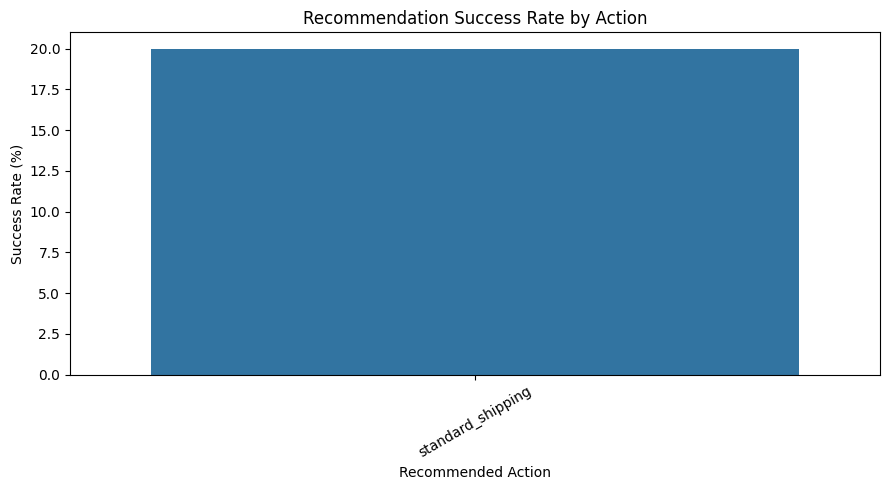

In [13]:
plt.figure(figsize=(9, 5))
sns.barplot(data=action_summary, x="recommended_action", y="success_rate")
plt.xlabel("Recommended Action")
plt.ylabel("Success Rate (%)")
plt.title("Recommendation Success Rate by Action")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


## 8.14 Visualize Actual Delay by Recommended Action


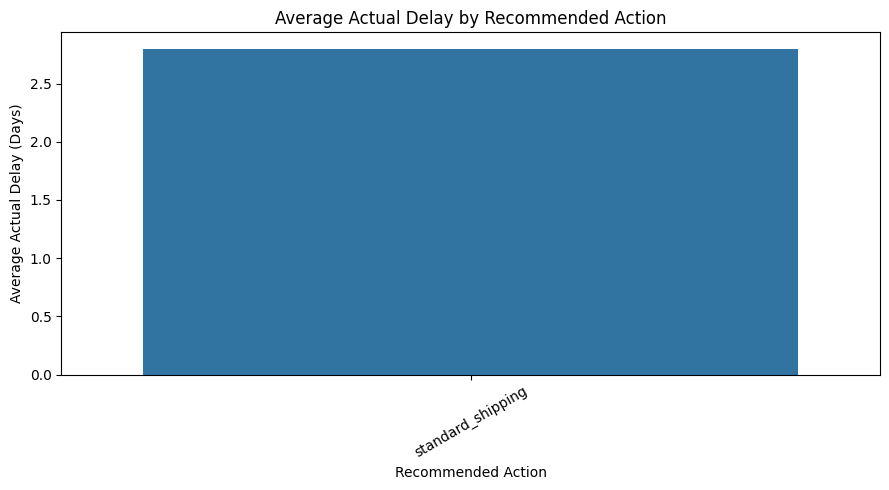

In [14]:
plt.figure(figsize=(9, 5))
sns.barplot(data=action_summary, x="recommended_action", y="average_actual_delay")
plt.xlabel("Recommended Action")
plt.ylabel("Average Actual Delay (Days)")
plt.title("Average Actual Delay by Recommended Action")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


## 8.15 Generate Feedback Records


In [15]:
feedback_columns = [
    "shipment_index", "delay_probability", "risk_level",
    "recommended_action", "manager_decision", "additional_cost",
    "actual_cost", "cost_difference", "expected_delay_risk",
    "actual_delay_days", "outcome_status",
    "recommendation_followed", "recommendation_success"
]

feedback_data = decision_log[feedback_columns].copy()
feedback_data.head(10)


,shipment_index,delay_probability,risk_level,recommended_action,manager_decision,additional_cost,actual_cost,cost_difference,expected_delay_risk,actual_delay_days,outcome_status,recommendation_followed,recommendation_success
0,0,0.000245,Low Risk,standard_shipping,air_freight,0,1576,1576,0.000245,0,Successful,False,False
1,1,0.000367,Low Risk,standard_shipping,standard_shipping,0,610,610,0.000367,4,Delayed,True,False
2,2,0.000059,Low Risk,standard_shipping,standard_shipping,0,2291,2291,0.000059,3,Delayed,True,False
3,3,0.234605,Low Risk,standard_shipping,standard_shipping,0,1182,1182,0.234605,2,Delayed,True,False
4,4,0.705212,High Risk,standard_shipping,standard_shipping,0,774,774,0.705212,2,Delayed,True,False
5,5,0.005539,Low Risk,standard_shipping,air_freight,0,802,802,0.005539,5,Delayed,False,False
6,6,0.999935,High Risk,standard_shipping,standard_shipping,0,0,0,0.999935,0,Successful,True,True
7,7,0.000356,Low Risk,standard_shipping,standard_shipping,0,0,0,0.000356,4,Delayed,True,False
8,8,0.999754,High Risk,standard_shipping,standard_shipping,0,1218,1218,0.999754,1,Successful,True,True
9,9,0.999889,High Risk,standard_shipping,standard_shipping,0,2552,2552,0.999889,0,Successful,True,True


## 8.16 Identify Cases for Future Review


In [16]:
review_cases = feedback_data[
    (~feedback_data["recommendation_followed"])
    | (~feedback_data["recommendation_success"])
]

print("Cases requiring review:", len(review_cases))
review_cases.head(10)


Cases requiring review: 20


,shipment_index,delay_probability,risk_level,recommended_action,manager_decision,additional_cost,actual_cost,cost_difference,expected_delay_risk,actual_delay_days,outcome_status,recommendation_followed,recommendation_success
0,0,0.000245,Low Risk,standard_shipping,air_freight,0,1576,1576,0.000245,0,Successful,False,False
1,1,0.000367,Low Risk,standard_shipping,standard_shipping,0,610,610,0.000367,4,Delayed,True,False
2,2,0.000059,Low Risk,standard_shipping,standard_shipping,0,2291,2291,0.000059,3,Delayed,True,False
3,3,0.234605,Low Risk,standard_shipping,standard_shipping,0,1182,1182,0.234605,2,Delayed,True,False
4,4,0.705212,High Risk,standard_shipping,standard_shipping,0,774,774,0.705212,2,Delayed,True,False
5,5,0.005539,Low Risk,standard_shipping,air_freight,0,802,802,0.005539,5,Delayed,False,False
7,7,0.000356,Low Risk,standard_shipping,standard_shipping,0,0,0,0.000356,4,Delayed,True,False
10,10,0.000063,Low Risk,standard_shipping,air_freight,0,0,0,0.000063,3,Delayed,False,False
11,11,0.999980,High Risk,standard_shipping,standard_shipping,0,2434,2434,0.999980,5,Delayed,True,False
12,12,0.001405,Low Risk,standard_shipping,standard_shipping,0,2311,2311,0.001405,4,Delayed,True,False


## 8.17 Create a Closed-Loop Performance Summary


In [17]:
closed_loop_summary = pd.DataFrame({
    "Metric": [
        "Total Decisions", "Recommendations Followed",
        "Recommendations Not Followed", "Successful Recommendations",
        "Unsuccessful Recommendations", "Recommendation Follow-Through Rate (%)",
        "Overall Success Rate (%)", "Average Estimated Cost",
        "Average Actual Cost", "Average Cost Difference",
        "Average Actual Delay (Days)"
    ],
    "Value": [
        len(decision_log), followed_count, not_followed_count,
        int(decision_log["recommendation_success"].sum()),
        int((~decision_log["recommendation_success"]).sum()),
        followed_percentage, success_rate, average_estimated_cost,
        average_actual_cost, average_cost_difference,
        decision_log["actual_delay_days"].mean()
    ]
})

closed_loop_summary


,Metric,Value
0,Total Decisions,25.00
1,Recommendations Followed,20.00
2,Recommendations Not Followed,5.00
3,Successful Recommendations,5.00
4,Unsuccessful Recommendations,20.00
5,Recommendation Follow-Through Rate (%),80.00
6,Overall Success Rate (%),24.00
7,Average Estimated Cost,0.00
8,Average Actual Cost,1268.08
9,Average Cost Difference,1268.08


## 8.18 Save the Closed-Loop Decision Log


In [18]:
DECISION_LOG_PATH = os.path.join(PROCESSED_DIR, "closed_loop_decision_log.csv")
os.makedirs(PROCESSED_DIR, exist_ok=True)
decision_log.to_csv(DECISION_LOG_PATH, index=False)
print("Decision log saved to:")
print(DECISION_LOG_PATH)


Decision log saved to:
c:\Users\USER\OneDrive\Desktop\VSCode\c++\SupplyPrescript\data\processed\closed_loop_decision_log.csv


## 8.19 Save the Feedback Dataset


In [19]:
FEEDBACK_PATH = os.path.join(PROCESSED_DIR, "closed_loop_feedback.csv")
feedback_data.to_csv(FEEDBACK_PATH, index=False)
print("Feedback dataset saved to:")
print(FEEDBACK_PATH)


Feedback dataset saved to:
c:\Users\USER\OneDrive\Desktop\VSCode\c++\SupplyPrescript\data\processed\closed_loop_feedback.csv


## 8.20 Save the Action Summary


In [20]:
ACTION_SUMMARY_PATH = os.path.join(PROCESSED_DIR, "action_performance_summary.csv")
action_summary.to_csv(ACTION_SUMMARY_PATH, index=False)
print("Action summary saved to:")
print(ACTION_SUMMARY_PATH)


Action summary saved to:
c:\Users\USER\OneDrive\Desktop\VSCode\c++\SupplyPrescript\data\processed\action_performance_summary.csv


## 8.21 Validate Saved Files


In [21]:
for path in [DECISION_LOG_PATH, FEEDBACK_PATH, ACTION_SUMMARY_PATH]:
    print(path, "->", os.path.exists(path))


c:\Users\USER\OneDrive\Desktop\VSCode\c++\SupplyPrescript\data\processed\closed_loop_decision_log.csv -> True
c:\Users\USER\OneDrive\Desktop\VSCode\c++\SupplyPrescript\data\processed\closed_loop_feedback.csv -> True
c:\Users\USER\OneDrive\Desktop\VSCode\c++\SupplyPrescript\data\processed\action_performance_summary.csv -> True


# 8.22 Closed-Loop Analytics Interpretation

The prototype stores the full decision lifecycle:

1. **Prediction** — XGBoost estimates delay probability.
2. **Recommendation** — PuLP selects an operational action.
3. **Human Decision** — the manager decision is recorded.
4. **Actual Outcome** — actual delay and cost are recorded.
5. **Evaluation** — the recommendation is compared with the outcome.
6. **Feedback** — the resulting record becomes feedback for future improvement.

This provides the foundation for continuous improvement without falsely claiming that automatic retraining is already implemented.


# Summary

Notebook 8 completes the prototype closed-loop analytics layer of SupplyPrescript.

### Outputs
- `closed_loop_decision_log.csv`
- `closed_loop_feedback.csv`
- `action_performance_summary.csv`

### Project Flow
**Predict → Prescribe → Decide → Observe → Evaluate → Learn**

### Limitation
Manager decisions, actual costs, and actual delay values in this notebook are demonstration data because the current project does not yet contain a real operational feedback database. In production, these fields should come from a backend database, ERP system, or user interface.

### Future Enhancement
After sufficient real-world feedback is collected, the system can periodically recalibrate optimization parameters and retrain the predictive model.


# End of Notebook 8
